In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

2026-01-06 14:36:02.379124: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-06 14:36:02.379198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-06 14:36:02.534422: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-06 14:36:02.798465: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## missing time coordinate so include helper function

In [2]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

## open_mfdataset() and fix time issue (start 01-01 not 02-01)

In [3]:
# grabbing both ohc and ssh
# using ssh to mask land pixels later

ds_ohc = xr.open_mfdataset(
    '/glade/campaign/cgd/cas/fasullo/E3SMLEv2/ocn/month_1/heat700/v2.FV1.piControl.heat700.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

ds_ssh = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/ocn/proc/tseries/month_1/v2.FV1.piControl.mpaso.hist.am.timeMonthly_avg_ssh.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

In [4]:
ds_ohc

<xarray.Dataset> Size: 5GB
Dimensions:    (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time       (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-01 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds   (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds   (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw         (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area       (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    heat700    (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds  (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

In [5]:
ds_ssh

<xarray.Dataset> Size: 5GB
Dimensions:              (time: 6000, lat: 180, nbnd: 2, lon: 360)
Coordinates:
  * lat                  (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon                  (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 357.5 358.5 359.5
  * time                 (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-0...
Dimensions without coordinates: nbnd
Data variables:
    lat_bnds             (time, lat, nbnd) float64 17MB dask.array<chunksize=(120, 180, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 35MB dask.array<chunksize=(120, 360, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(120, 180), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    timeMonthly_avg_ssh  (time, lat, lon) float32 2GB dask.array<chunksize=(120, 180, 360), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(6000, 2), meta=np.ndarray>
Attributes: (12/749)
    title:                                                        MPAS-Ocean ...
    source:                                                       MPAS Ocean
    source_id:                                                    96c3ee8f6d
    product:                                                      model-output
    realm:                                                        ocean
    case:                                                         v2.LR.piCon...
    ...                                                           ...
    remap_script:                                                 ncremap
    remap_hostname:                                               nid00846
    remap_version:                                                5.0.1
    nco_openmp_thread_number:                                     2
    map_file:                                                     /global/u2/...
    input_file:                                                   ./ncremap_t...

In [6]:
# fix start time
ds_ohc = ds_ohc.assign_coords(
    time=ds_ohc['time'] - xr.coding.cftime_offsets.MonthBegin(1)
)

ds_ssh = ds_ssh.assign_coords(
    time=ds_ssh['time'] - xr.coding.cftime_offsets.MonthBegin(1)
)

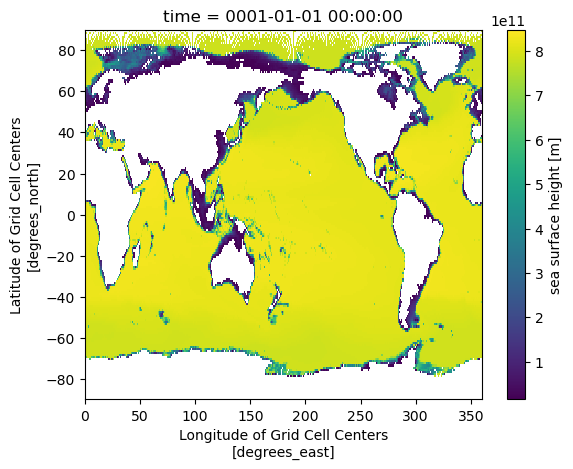

In [9]:
# checking our sanity
ds_ohc['heat700'].isel(time=0).where(
    ds_ohc['heat700'].isel(time=0) <= 1e35, np.nan).plot()

## Slice files to Tropical Pacific Region

In [10]:
print(
    ds_ohc['heat700'].shape,
    ds_ssh['timeMonthly_avg_ssh'].shape
)

(6000, 180, 360) (6000, 180, 360)


In [11]:
# grab variables
ds_ohc = ds_ohc['heat700']
ds_ssh = ds_ssh['timeMonthly_avg_ssh']

In [14]:
# new spatial bounds
ds_ohc_tp = ds_ohc.sel(lat=slice(-10, 10), lon=slice(130, 280))
ds_ssh_tp = ds_ssh.sel(lat=slice(-10, 10), lon=slice(130, 280))

In [15]:
print(ds_ohc_tp.shape, ds_ssh_tp.shape)

(6000, 20, 150) (6000, 20, 150)


## Look for NaN values and use SSH to mask, then extraneous data points in OHC to mask

In [16]:
# Check if there are any NaN values in the SSH dataset
has_nan = ds_ssh_tp.isnull().any()

print(f"SSH dataset contains NaN values: {has_nan.values}")

# Count the number of NaN values in the SSH dataset
nan_count = ds_ssh_tp.isnull().sum()
print(f"Number of NaN values in SSH dataset: {nan_count.values}")

SSH dataset contains NaN values: True
Number of NaN values in SSH dataset: 192000


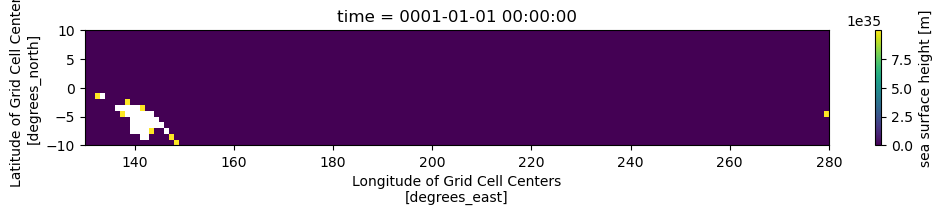

In [17]:
# Mask land pixels in OHC data using the NaN values in SSH data
ohc_ocean_only = ds_ohc_tp.where(~ds_ssh_tp.isnull(), np.nan)

# Plot to confirm that land areas are masked
ohc_ocean_only[0].plot.pcolormesh(figsize=(12, 1.5))

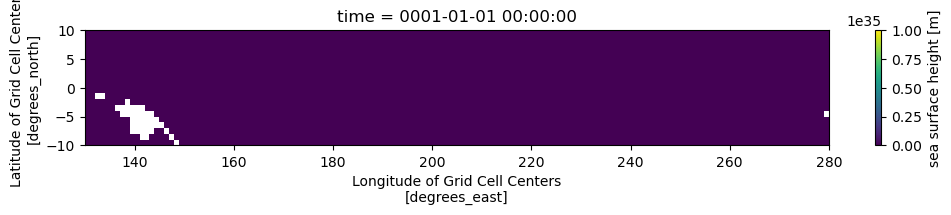

In [18]:
ohc_ocean_only[0].where(ohc_ocean_only[0] <= 1e35, np.nan).plot.pcolormesh(
    figsize=(12, 1.5), vmin=0, vmax=1e35)

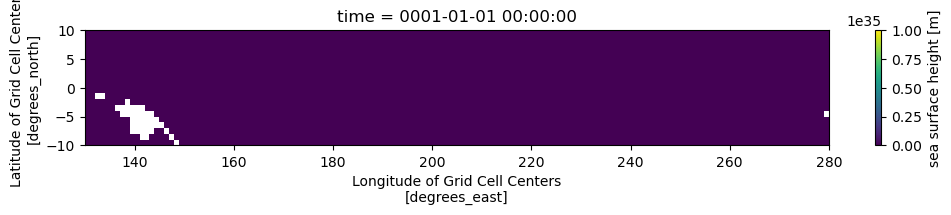

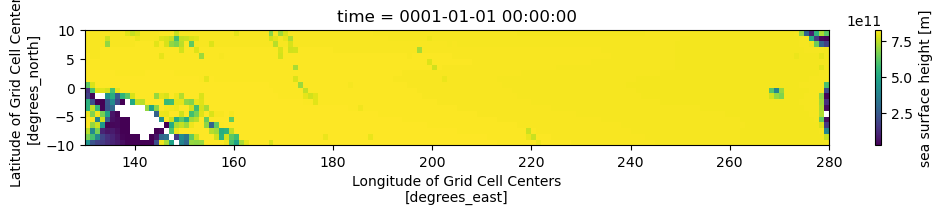

In [19]:
# Mask values that are either greater than 1e35 or equal to -9.4371840e+06 in the OHC data
# Apply the first condition for values less than or equal to 1e35
valid_ohc = ohc_ocean_only.where(ohc_ocean_only[0] <= 1e35, np.nan)

valid_ohc[0].plot.pcolormesh(figsize=(12, 1.5), vmin=0, vmax=1e35); plt.show()
valid_ohc[0].plot.pcolormesh(figsize=(12, 1.5)); plt.show()

In [20]:
# check shapes
print(ds_ssh_tp.shape,
      ohc_ocean_only.shape,
      valid_ohc.shape
     )

(6000, 20, 150) (6000, 20, 150) (6000, 20, 150)


### Anoms

In [21]:
# climatology and anomalies
tmpclim = valid_ohc.groupby('time.month').mean(dim='time', keep_attrs=True)
tmpanom = valid_ohc.groupby('time.month') - tmpclim

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


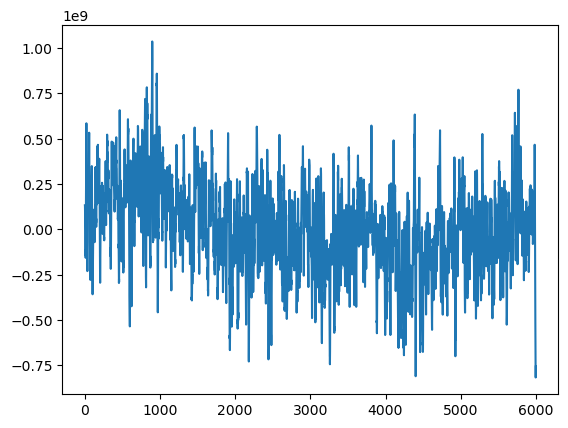

In [22]:
plt.plot(range(0,6000), tmpanom.mean(dim=['lat','lon']))
plt.show()

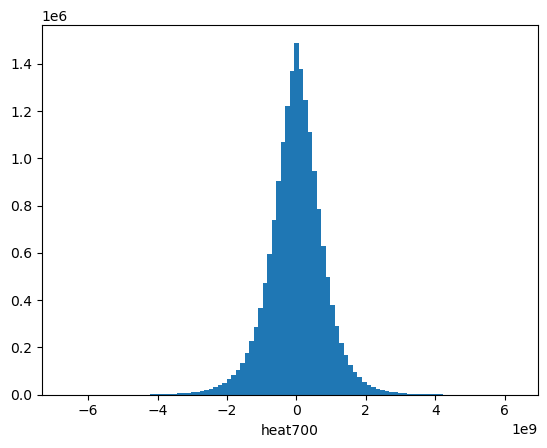

In [23]:
tmpanom.stack(newdim=['time', 'lon', 'lat']).plot.hist(bins=100)
plt.show()

In [24]:
print(tmpanom.min().values, tmpanom.max().values)

-6685065000.0 6303711000.0


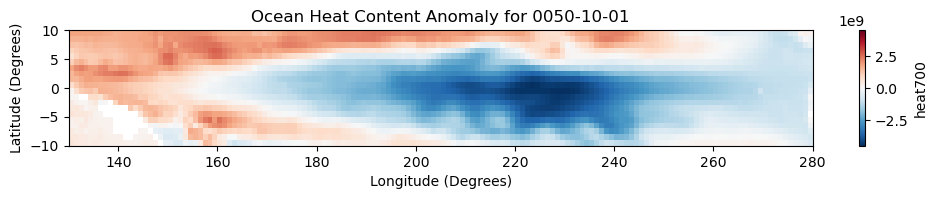

In [25]:
tmpanom.isel(time=597).plot.pcolormesh(figsize=(12, 1.5))
plt.title('Ocean Heat Content Anomaly for 0050-10-01')
plt.xlabel('Longitude (Degrees)')
plt.ylabel('Latitude (Degrees)')
plt.show()

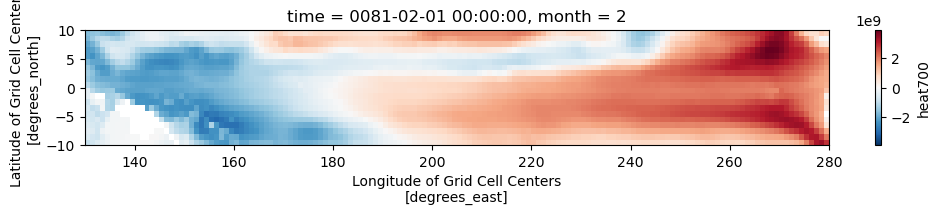

In [26]:
tmpanom.isel(time=961).plot.pcolormesh(figsize=(12, 1.5))

In [27]:
tmpanom

<xarray.DataArray 'heat700' (time: 6000, lat: 20, lon: 150)> Size: 72MB
dask.array<sub, shape=(6000, 20, 150), dtype=float32, chunksize=(1, 20, 150), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 160B -9.5 -8.5 -7.5 -6.5 -5.5 ... 5.5 6.5 7.5 8.5 9.5
  * lon      (lon) float64 1kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

# How to do grid reconstruction [from Maria]

In [29]:
def create_index_mask(da):
    """
    Create index mask for reconstruction of predictions.
    Args:
        da (xarray data array): 2d input variable samples
    Returns:
        y_, x_ (numpy arrays): x and y indices for reconstruction
    """
    # just one sample needed; time=0
    da = da.isel(time=0)
    
    # original 2d grid shape
    orig_2d_shape = da.shape
    
    # location of the valid values (not nan) in 1d vector
    orig_indx = np.where(~np.isnan(da.stack(newdim=['lat', 'lon']).values))[0]
    
    # Indices of non-nan values in original 2d grid
    y_, x_ = np.unravel_index(orig_indx, orig_2d_shape)
    
    # return the respective indices for (20, 150)
    return y_, x_

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d.values
    
    # return predictions on original 2d grid
    return pred_grid

In [30]:
# produce the indices to be used
y_vals, x_vals = create_index_mask(tmpanom)

# save the numpy arrays of the y, x indices
np.save('ohc_yindx.npy', y_vals)
np.save('ohc_xindx.npy', x_vals)

In [31]:
# indices can be loaded anytime and used for reconstruction
yindx = np.load('ohc_yindx.npy')
xindx = np.load('ohc_xindx.npy')

### fake predictions here just using actual data
# flattened grid shape
heat_newdim = tmpanom.stack(newdim=['lat', 'lon'])
# flattened grid shape after dropping nans
heat_processed = heat_newdim.dropna('newdim', how='any')

# now reconstruct fake predictions
predictions_2d = reconstruct_grid(heat_processed, yindx, xindx)

# can close files like this
del yindx
del xindx

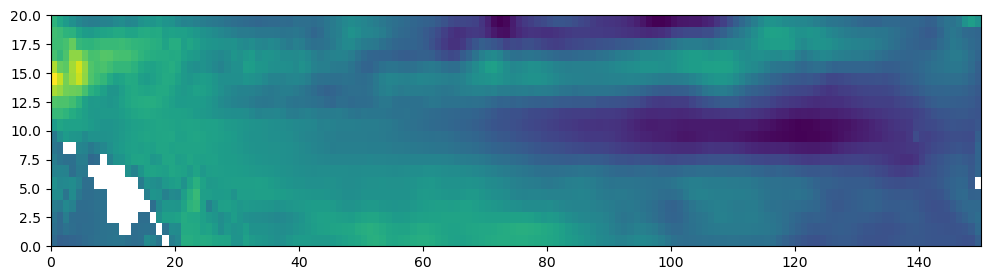

In [32]:
# quick viz of reconstruction
plt.figure(figsize=(12,3))
plt.pcolormesh(predictions_2d[0,:,:])
plt.show()

## Split into Train/Test

In [33]:
heat_train, heat_test = train_test_split(
    heat_processed, test_size=0.2, random_state=0, shuffle=True
)

In [34]:
print(heat_train.shape, heat_test.shape)

(4800, 2960) (1200, 2960)


In [35]:
heat_train

<xarray.DataArray 'heat700' (time: 4800, newdim: 2960)> Size: 57MB
dask.array<getitem, shape=(4800, 2960), dtype=float32, chunksize=(1, 2960), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [36]:
heat_test

<xarray.DataArray 'heat700' (time: 1200, newdim: 2960)> Size: 14MB
dask.array<getitem, shape=(1200, 2960), dtype=float32, chunksize=(1, 2960), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

## Use Robust Scaler

In [80]:
from sklearn.preprocessing import RobustScaler

heat_train_tmp = heat_train.copy()
heat_train_tmp = heat_train_tmp.values

scaler_tmp = RobustScaler()
scaler_tmp_ohc = scaler_tmp.fit(heat_train_tmp.reshape(4800 * 2960, 1))

In [83]:
scaler = RobustScaler()

scaler_ohc = scaler.fit(heat_train)

In [90]:
scaler_ohc.center_ = np.repeat(scaler_tmp_ohc.center_, 2960)

In [93]:
scaler_ohc.scale_ = np.repeat(scaler_tmp_ohc.scale_, 2960)

In [95]:
scaled_input_ohc_train = scaler_ohc.transform(heat_train)

scaled_input_ohc_test = scaler_ohc.transform(heat_test)

print(scaled_input_ohc_train.shape, scaled_input_ohc_test.shape)

(4800, 2960) (1200, 2960)


In [123]:
import joblib

# Save the scaler to a file
joblib.dump(scaler_ohc, 'scaler_ohc_700_0228.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


In [96]:
scaled_input_ohc_train[:-10]

array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.21451738, -0.10156927, -0.07002114, ..., -0.19644858,
        -0.37717277, -0.491729  ],
       [ 0.02131667,  0.15836857,  0.19616851, ..., -0.4157316 ,
        -0.6355567 , -0.6220412 ],
       [-0.2618215 , -0.3238698 , -0.32372525, ...,  0.12279109,
         0.18389979,  0.1512314 ]], dtype=float32)

In [97]:
scaled_input_ohc_test[:10]

array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.30109406,  0.37177923,  0.35432476, ...,  0.03533807,
         0.04346903,  0.07490876],
       [-0.43249947, -0.34618476, -0.3070658 , ...,  0.3706951 ,
         0.50530773,  0.42089024],
       [ 0.6474369 ,  0.49840543,  0.4756568 , ...,  0.26033083,
         0.30987552,  0.17284168]], dtype=float32)

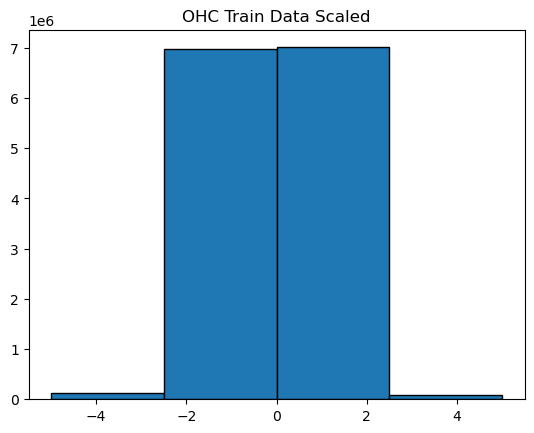

In [98]:
plt.hist(scaled_input_ohc_train.flatten(), 
         bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Train Data Scaled')
plt.show()

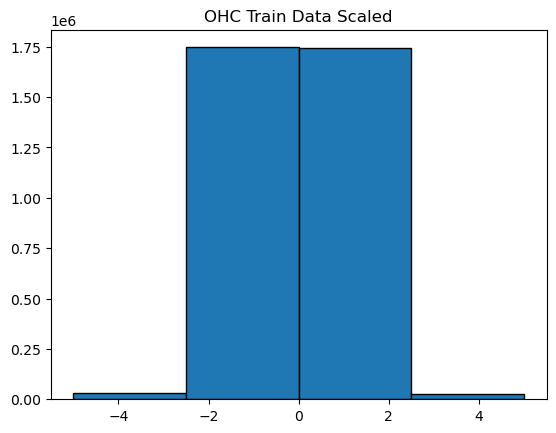

In [99]:
plt.hist(scaled_input_ohc_test.flatten(), bins=[-5,-2.5,0,2.5,5],
        lw=1, edgecolor='k')
plt.title('OHC Train Data Scaled')
plt.show()

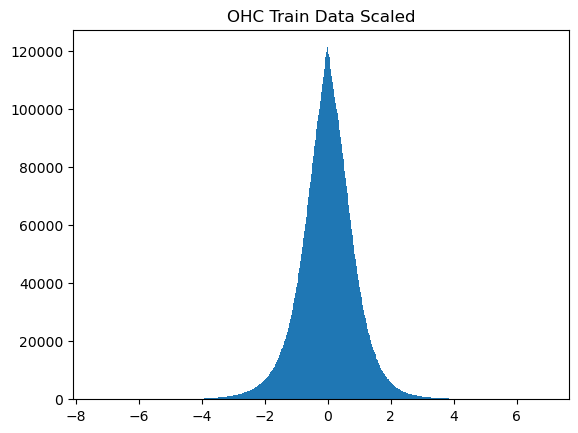

In [100]:
plt.hist(
    scaled_input_ohc_train.flatten(),
    bins=1000,
)
plt.title('OHC Train Data Scaled')
plt.show()

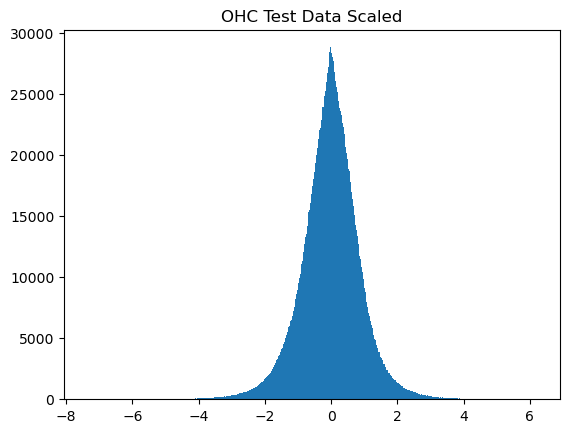

In [101]:
plt.hist(
    scaled_input_ohc_test.flatten(),
    bins=1000,
)
plt.title('OHC Test Data Scaled')
plt.show()

## Save out files

In [124]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

## RETAIN TIME COMPONENT FOR SORTING LATER ON

In [125]:
scaled_input_ohc_train

array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)

In [126]:
scaled_input_ohc_test

array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)

In [127]:
import xarray as xr

# Get original coordinates for each dimension
coords = heat_train.coords  # Retains 'time', 'lat', 'lon', etc.
dims = heat_train.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
heat_train_coords = xr.DataArray(scaled_input_ohc_train, dims=dims, coords=coords)

In [128]:
heat_train_coords

<xarray.DataArray (time: 4800, newdim: 2960)> Size: 57MB
array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [129]:
# Get original coordinates for each dimension
coords = heat_test.coords  # Retains 'time', 'lat', 'lon', etc.
dims = heat_test.dims      # Keeps the dimensions as ('newdim',)

# Create a new DataArray with the scaled data and the original coordinates
heat_test_coords = xr.DataArray(scaled_input_ohc_test, dims=dims, coords=coords)

In [130]:
heat_test_coords

<xarray.DataArray (time: 1200, newdim: 2960)> Size: 14MB
array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
  * newdim   (newdim) object 24kB MultiIndex
  * lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
  * lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5

In [131]:
print(heat_train_coords.shape, heat_test_coords.shape)

(4800, 2960) (1200, 2960)


In [132]:
# Convert MultiIndex levels in `newdim` into separate coordinates
ohc_train_reset_index = heat_train_coords.reset_index('newdim')

In [133]:
ohc_train_reset_index

<xarray.DataArray (time: 4800, newdim: 2960)> Size: 57MB
array([[-0.42270616, -0.27264473, -0.24234334, ..., -0.05016352,
        -0.04759775,  0.07686018],
       [ 0.12123717, -0.06499802, -0.13002765, ...,  0.13092205,
         0.25949967,  0.2127376 ],
       [ 0.00483792, -0.03959327, -0.0446164 , ...,  0.41673443,
         0.6304161 ,  0.5665971 ],
       ...,
       [-0.08966193, -0.01263461,  0.04462544, ..., -0.23713952,
        -0.29962146, -0.18520978],
       [-0.51023144, -0.20279072, -0.12083063, ...,  0.11299779,
         0.16922791,  0.13041613],
       [-0.5901317 , -0.37921456, -0.23081544, ..., -0.05471686,
        -0.06385968, -0.04535722]], dtype=float32)
Coordinates:
  * time     (time) object 38kB 0282-10-01 00:00:00 ... 0228-09-01 00:00:00
    month    (time) int64 38kB 10 8 1 7 2 5 1 2 10 10 ... 7 6 2 8 12 12 1 10 4 9
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [134]:
# Convert MultiIndex levels in `newdim` into separate coordinates
ohc_test_reset_index = heat_test_coords.reset_index('newdim')

In [135]:
ohc_test_reset_index

<xarray.DataArray (time: 1200, newdim: 2960)> Size: 14MB
array([[ 0.27984515,  0.1208758 ,  0.0409394 , ..., -0.13736358,
        -0.19034132, -0.16533409],
       [-0.0235301 , -0.05337977, -0.12280012, ...,  0.18595964,
         0.30069655,  0.34529036],
       [-1.0816755 , -0.8742637 , -0.6106579 , ...,  0.1987885 ,
         0.382223  ,  0.3536743 ],
       ...,
       [ 0.03298912,  0.10255402,  0.14069727, ...,  0.14100444,
         0.2600056 ,  0.14732853],
       [ 0.35562572,  0.37593505,  0.38173515, ...,  0.13561994,
         0.16496368,  0.16337363],
       [-0.9116842 , -0.61154324, -0.50289553, ...,  0.32816115,
         0.4723502 ,  0.46367717]], dtype=float32)
Coordinates:
  * time     (time) object 10kB 0361-01-01 00:00:00 ... 0397-03-01 00:00:00
    month    (time) int64 10kB 1 3 2 5 3 6 12 5 6 11 ... 11 1 12 9 1 3 3 10 5 3
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [136]:
# Save the xarray DataArray to a NetCDF file
heat_train = ohc_train_reset_index.to_netcdf('ohc700_train_robustscaler.nc')
heat_test = ohc_test_reset_index.to_netcdf('ohc700_test_robustscaler.nc')

In [137]:
# ohc train and test
savetxt('ohc700_train_robustscaler.csv',
        scaled_input_ohc_train, delimiter=',')
savetxt('ohc700_test_robustscaler.csv',
        scaled_input_ohc_test, delimiter=',')